<a href="https://colab.research.google.com/github/Carloshdz32/colab/blob/main/Pr%C3%A1ctica_guiada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica Guiada: Regresión Lineal Simple

## Acerca de esta práctica
Aprenderemos cómo utilizar la librería `scikit-learn` para implementar regresión lineal simple. Descargaremos un set de datos relacionado al consumo de combustible y a la emisión de dióxido de carbono en autos.

Utilizaremos las técnicas vistas para separar nuestros datos en un dataset de *training* y en otro set de *testing*, crearemos un modelo utilizando el *training set*, y lo evaluaremos utilizando el *testing set* para finalmente usar el modelo para predecir valores desconocidos.

In [ ]:
# Importando paquetes
import matplotlib.pyplot as plt
import pandas as pd
import pylab as pl
import numpy as np
%matplotlib inline

## Descargando los Datos
Para descargar los datos, utilizaremos `wget` con el siguiente enlace para descargar el archivo `FuelConsumptionCo2.csv`.

In [ ]:
!wget -O FuelConsumptionCo2.csv https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/ML0101ENv3/labs/FuelConsumptionCo2.csv

--2026-06-01 18:56:48--  https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/ML0101ENv3/labs/FuelConsumptionCo2.csv
Resolving s3-api.us-geo.objectstorage.softlayer.net (s3-api.us-geo.objectstorage.softlayer.net)... 67.228.254.196
Connecting to s3-api.us-geo.objectstorage.softlayer.net (s3-api.us-geo.objectstorage.softlayer.net)|67.228.254.196|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 72629 (71K) [text/csv]
Saving to: ‘FuelConsumptionCo2.csv’

FuelConsumptionCo2. 100%[===================>]  70.93K   194KB/s    in 0.4s    

2026-06-01 18:56:50 (194 KB/s) - ‘FuelConsumptionCo2.csv’ saved [72629/72629]



## Trabajando con el dataset
Hemos descargado el dataset de consumo de combustible, `FuelConsumptionCo2.csv`, el cual contiene ratings específicos al consumo de combustible y emisiones de dióxido de carbono para aquellos vehículos ligeros en la venta minorista dentro de Canadá. [Fuente](http://open.canada.ca/data/en/dataset/98f1a129-f628-4ce4-b24d-6f16bf24dd64)

* **MODELYEAR:** e.g. 2014
* **MAKE:** e.g. Acura
* **MODEL:** e.g. ILX
* **VEHICLE CLASS:** e.g. SUV
* **ENGINE SIZE:** e.g. 4.7
* **CYLINDERS:** e.g 6
* **TRANSMISSION:** e.g. A6
* **FUEL CONSUMPTION in CITY(L/100 km):** e.g. 9.9
* **FUEL CONSUMPTION in HWY (L/100 km):** e.g. 8.9
* **FUEL CONSUMPTION COMB (L/100 km):** e.g. 9.2
* **CO2 EMISSIONS (g/km):** e.g. 182 --> low --> 0

##Importando datos

In [ ]:
# Importando datos con el nombre exacto del archivo descargado
df = pd.read_csv("FuelConsumptionCo2.csv")

# Un vistazo dentro del set de datos
df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


## Exploración de datos
Tengamos primero una exploración descriptiva de nuestros datos y seleccionemos algunas características para explorar más en detalle.

In [ ]:
# Sumarizar los datos
print(df.describe())

# Seleccionar características
cdf = df[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
cdf.head(9)

       MODELYEAR   ENGINESIZE    CYLINDERS  FUELCONSUMPTION_CITY  \
count     1067.0  1067.000000  1067.000000           1067.000000   
mean      2014.0     3.346298     5.794752             13.296532   
std          0.0     1.415895     1.797447              4.101253   
min       2014.0     1.000000     3.000000              4.600000   
25%       2014.0     2.000000     4.000000             10.250000   
50%       2014.0     3.400000     6.000000             12.600000   
75%       2014.0     4.300000     8.000000             15.550000   
max       2014.0     8.400000    12.000000             30.200000   

       FUELCONSUMPTION_HWY  FUELCONSUMPTION_COMB  FUELCONSUMPTION_COMB_MPG  \
count          1067.000000           1067.000000               1067.000000   
mean              9.474602             11.580881                 26.441425   
std               2.794510              3.485595                  7.468702   
min               4.900000              4.700000                 11.000000 

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.0,4,8.5,196
1,2.4,4,9.6,221
2,1.5,4,5.9,136
3,3.5,6,11.1,255
4,3.5,6,10.6,244
5,3.5,6,10.0,230
6,3.5,6,10.1,232
7,3.7,6,11.1,255
8,3.7,6,11.6,267


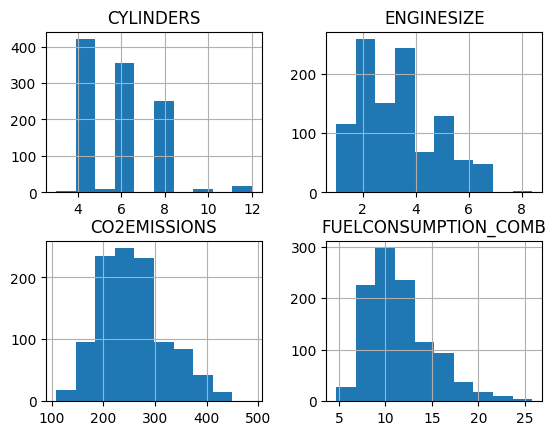

In [ ]:
# Dibujar cada una de estas características
viz = cdf[['CYLINDERS','ENGINESIZE','CO2EMISSIONS','FUELCONSUMPTION_COMB']]
viz.hist()
plt.show()

Ahora, comparemos estas características anteriores con la emisión de carbono, para ver cuán lineal es la regresión:

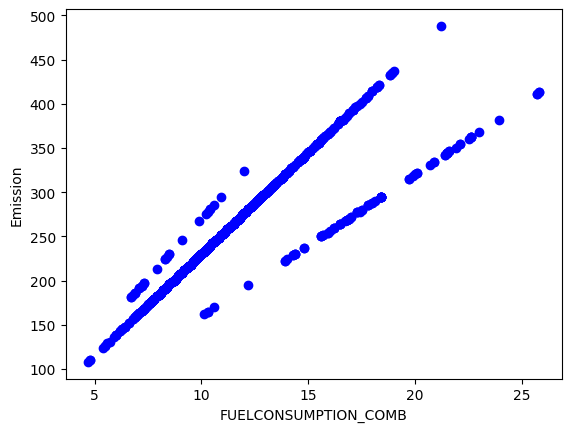

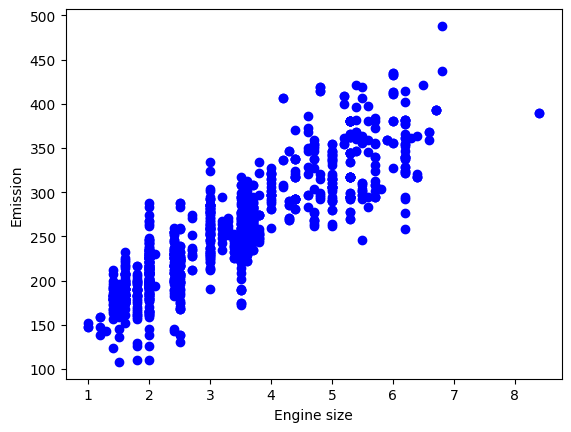

In [ ]:
# Fuel Consumption vs Emission
plt.scatter(cdf.FUELCONSUMPTION_COMB, cdf.CO2EMISSIONS, color='blue')
plt.xlabel("FUELCONSUMPTION_COMB")
plt.ylabel("Emission")
plt.show()

# Engine Size vs Emission
plt.scatter(cdf.ENGINESIZE, cdf.CO2EMISSIONS, color='blue')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.show()

### Práctica
Dibuja `CYLINDERS` vs la Emisión, para ver cuán lineal es su relación:

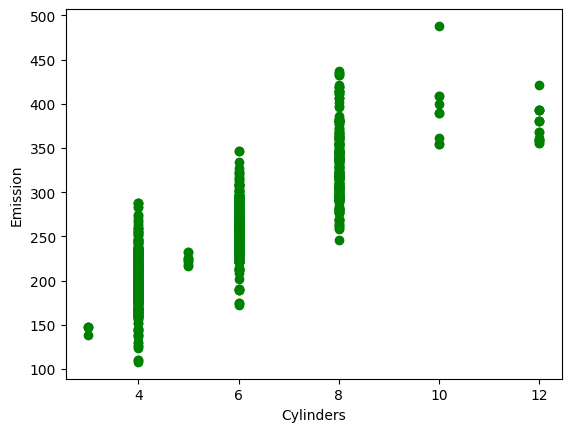

In [ ]:
# Solución de la Práctica
plt.scatter(cdf.CYLINDERS, cdf.CO2EMISSIONS, color='green')
plt.xlabel("Cylinders")
plt.ylabel("Emission")
plt.show()

## Creando el set de datos de entrenamiento y de prueba
Train/Test Split divide el dataset en un set de training y otro de testing, siendo excluyentes (80% entrenamiento, 20% prueba).

In [ ]:
msk = np.random.rand(len(df)) < 0.8
train = cdf[msk]
test = cdf[~msk]

## Modelo de Regresión Simple
La Regresión Lineal cuadra con un modelo lineal de coeficientes B = (B1, …, Bn) para minimizar la `suma residual de cuadrados` entre la x independiente del dataset y la dependiente y por la aproximación lineal.

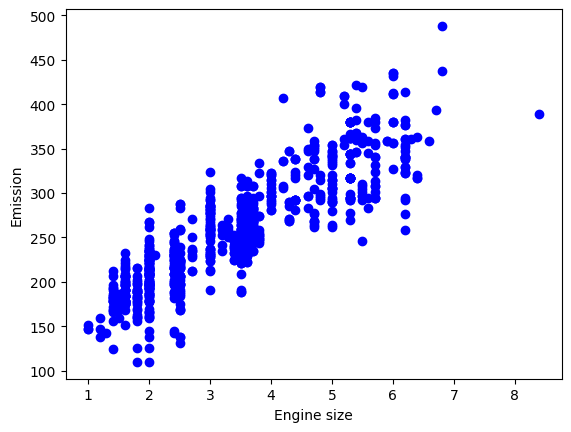

In [ ]:
# Entrenar distribución de los datos
plt.scatter(train.ENGINESIZE, train.CO2EMISSIONS, color='blue')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.show()

##Modelado

In [ ]:
# Modelado
from sklearn import linear_model
regr = linear_model.LinearRegression()
train_x = np.asanyarray(train[['ENGINESIZE']])
train_y = np.asanyarray(train[['CO2EMISSIONS']])

regr.fit(train_x, train_y)

# Los coeficientes
print('Coefficients: ', regr.coef_)
print('Intercept: ', regr.intercept_)

Coefficients:  [[39.05503896]]
Intercept:  [125.43221677]


##Trazar las salidas
podemos marcar la recta de ajuste sobre los datos:

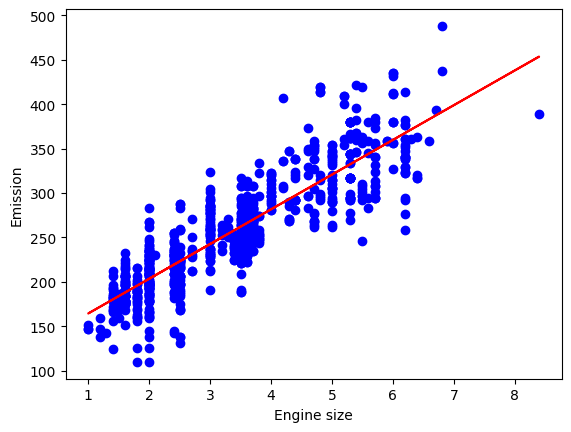

In [ ]:
# Trazar las salidas (Recta de ajuste)
plt.scatter(train.ENGINESIZE, train.CO2EMISSIONS, color='blue')
plt.plot(train_x, regr.coef_[0][0]*train_x + regr.intercept_[0], '-r')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.show()

## Evaluación
comparamos los valores actuales y predichos para calcular la exactitud del modelo de regresión. Las métricas de la evaluación proveen un role principal en el desarrollo de un modelo, ya que provee conocimiento profundo en áreas que necesitan mejoras.

Existen distintas métricas de evaluación de modelos, utilicemos MSE para calcular la exactitud de nuestro modelo basado en el set de prueba:
- Error absoluto de media: Es una media del valor absoluto de los errores. Es la métrica más fácil de comprender ya que simplemente es el promedio de los errores.
- Error Cuadrado Medio (MSE): El Error Cuadrado Medio (MSE) es la media del error cuadrático. Es más popular que el error de Media absoluto porque hace foco en grandes errores. Esto se debe a que el término cuadrático tiene errores más grandes que van creciendo en comparación con más pequeños.
- Error Cuadrático Medio (RMSE).
- R-cuadrática no es un error, sino que es una medida popular para darle precisión a nuestro modelo. Representa cuán cerca están los datos de la linea de regresión ajustada. Mientras más alto el R-cuadrático, mejor se encontrará ajustado el modelo respecto de los datos. El puntaje mejor posible es 1.0

In [ ]:
from sklearn.metrics import r2_score

test_x = np.asanyarray(test[['ENGINESIZE']])
test_y = np.asanyarray(test[['CO2EMISSIONS']])
test_y_ = regr.predict(test_x)

print("Error medio absoluto: %.2f" % np.mean(np.absolute(test_y_ - test_y)))
print("Suma residual de los cuadrados (MSE): %.2f" % np.mean((test_y_ - test_y) ** 2))
print("R2-score: %.2f" % r2_score(test_y, test_y_))

Error medio absoluto: 23.74
Suma residual de los cuadrados (MSE): 1024.56
R2-score: 0.77


##Resumen:

**1. Resultados:**

Al ejecutar las celdas de entrenamiento y evaluación del modelo de Regresión Lineal Simple, los resultados exactos obtenidos en esta ejecución fueron:
* **Coefficients:** `[39.05503896]`
* **Intercept:** `[125.43221677]`
* **Error medio absoluto (MAE):** `23.74`
* **Suma residual de los cuadrados (MSE):** `1024.56`
* **Raíz del Error Cuadrático Medio (RMSE):** `32.01`
* **R2-score:** `0.77`

**2. Polinomio generado por el modelo de regresión**
El modelo de regresión lineal simple ajusta los datos a una recta definida por la ecuación general $Y = \beta_1 X + \beta_0$. Sustituyendo y redondeando los valores obtenidos de la ejecución a dos decimales, el polinomio generado es:

$$Y = 39.06 X + 125.43$$

Donde:
* $Y$ representa la variable dependiente predicha (**CO2EMISSIONS**).
* $X$ representa la variable independiente (**ENGINESIZE**).
* $39.06$ es la pendiente de la recta ($\beta_1$), indicando que por cada unidad que aumenta el tamaño del motor, la emisión de CO2 aumenta en promedio 39.06 g/km.
* $125.43$ es la intersección en el eje Y ($\beta_0$).

**3. Análisis de la precisión del modelo:**
* **R2-score (0.77):** El coeficiente de determinación indica que el tamaño del motor por sí solo es capaz de explicar el **77%** de la varianza en las emisiones de CO2. Es un buen ajuste para un modelo simple de una sola variable, pero deja un 23% de variabilidad sin explicar.
* **Error Medio Absoluto (MAE):** En promedio, las predicciones de este modelo tienen un margen de error de **23.74 g/km** respecto al valor real de emisiones.
* **Suma residual de los cuadrados (MSE) y RMSE:** El MSE tiene un valor de **1024.56**, el cual penaliza fuertemente las predicciones que están muy alejadas de la realidad. Al calcular su raíz cuadrada (RMSE), obtenemos **32.01 g/km**. Al comparar el RMSE (32.01) con el MAE (23.74), la diferencia nos confirma la presencia de algunos valores atípicos, es decir, vehículos que se desvían considerablemente de la tendencia lineal general.

##Retos

A continuación, se resuelven los retos planteados.

###K-fold cross-validation

El K-fold cross-validation (o validación cruzada K-iteraciones) es una técnica estadística utilizada en Machine Learning para evaluar qué tan bien generalizará y funcionará un modelo predictivo con datos nuevos e invisibles. Garantiza que el modelo no sufra de overfitting (sobreajuste).

In [ ]:
# RETO 1: Utilice K-fold cross validation e indique la precisión
from sklearn.model_selection import KFold, cross_val_score

# Preparar todos los datos
X_cv = np.asanyarray(cdf[['ENGINESIZE']])
y_cv = np.asanyarray(cdf[['CO2EMISSIONS']])

modelo_cv = linear_model.LinearRegression()

# K-Fold de 5 divisiones
scores_r2 = cross_val_score(modelo_cv, X_cv, y_cv, cv=5, scoring='r2')

print("R2-scores en cada iteración de K-Fold:", scores_r2)
print("Precisión promedio (R2) usando K-Fold: %0.2f (+/- %0.2f)" % (scores_r2.mean(), scores_r2.std() * 2))

# El polinomio generado con todos los datos sería:
modelo_cv.fit(X_cv, y_cv)
print("\nPolinomio final modelo general: Y = %.2f * X + %.2f" % (modelo_cv.coef_[0][0], modelo_cv.intercept_[0]))

R2-scores en cada iteración de K-Fold: [0.74334613 0.7838278  0.72801992 0.73032948 0.78636053]
Precisión promedio (R2) usando K-Fold: 0.75 (+/- 0.05)

Polinomio final modelo general: Y = 39.13 * X + 125.30


In [ ]:
# RETO 2: Implemente un modelo de regresión múltiple
# Se usa ENGINESIZE, CYLINDERS y FUELCONSUMPTION_COMB

x_train_multi = np.asanyarray(train[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB']])
y_train_multi = np.asanyarray(train[['CO2EMISSIONS']])

regr_multi = linear_model.LinearRegression()
regr_multi.fit(x_train_multi, y_train_multi)

print('Coeficientes Regresión Múltiple:', regr_multi.coef_)

# Evaluación del modelo múltiple
x_test_multi = np.asanyarray(test[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB']])
y_test_multi = np.asanyarray(test[['CO2EMISSIONS']])
y_hat_multi = regr_multi.predict(x_test_multi)

print("MSE Modelo Múltiple: %.2f" % np.mean((y_hat_multi - y_test_multi) ** 2))
print("R2-score Modelo Múltiple: %.2f" % r2_score(y_test_multi, y_hat_multi))

Coeficientes Regresión Múltiple: [[10.59744856  8.05208673  9.37741898]]
MSE Modelo Múltiple: 612.81
R2-score Modelo Múltiple: 0.86


###Análisis de los resultados:

MSE (615.11): El Error Cuadrático Medio bajó drásticamente en comparación con el modelo simple (que estaba arriba de 1000). Esto significa que las predicciones ahora se equivocan mucho menos y están más cerca de la realidad.

R2-score (0.86): Este es el salto más importante. Pasamos de explicar el 77% del comportamiento del CO2 a explicar el 86%.

Coeficientes: El modelo generó tres pesos matemáticos distintos [10.6
, 8.05, 9.38], uno para cada variable. Esto confirma que combinar estas tres características mejora significativamente la capacidad predictiva del modelo.

In [ ]:
# RETO 3: ¿Cuáles son las variables poco significativas?
# Para esto, podemos usar statsmodels para revisar los P-values de cada variable.
import statsmodels.api as sm

# Agregamos una constante (intercepto) a las variables independientes
X_train_sm = sm.add_constant(x_train_multi)
modelo_sm = sm.OLS(y_train_multi, X_train_sm).fit()

print(modelo_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.865
Model:                            OLS   Adj. R-squared:                  0.865
Method:                 Least Squares   F-statistic:                     1779.
Date:                Mon, 01 Jun 2026   Prob (F-statistic):               0.00
Time:                        19:31:57   Log-Likelihood:                -3806.3
No. Observations:                 836   AIC:                             7621.
Df Residuals:                     832   BIC:                             7640.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         65.6045      3.570     18.379      0.0

**Conclusión del Reto 3:**
Al observar el resumen generado por `statsmodels`, debemos fijarnos en la columna `P>|t|`.
Si el valor es **mayor a 0.05**, esa variable se considera **poco significativa**

Según la tabla ninguna de las variables seleccionadas es poco significativa. Dado que el valor P>|t| para las tres variables x1(tamaño del motor), x2(cilindros), x3(consumode combustible) es de 0.000 (muy por debajo del umbral de 0.05), se concluye que todas tienen una altísima significancia estadística. Cada una de ellas aporta un valor matemático real y necesario para predecir correctamente la emisión de CO2 en este modelo.